In [2]:
print("""This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).""")

This script was written in support of the experiments carried out in:
Nic Ezzell, Lev Barash, Itay Hen, A universal black-box quantum Monte Carlo approach to quantum phase transitions, arXiv:2408.03924v2 (2025).


In [1]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import glob
import pandas as pd
import sys
import scipy
sys.path.append("../../utils")
from exact_calculations import (prl_gs_chiE, prl_gs_chiF, prl_beta_chiE,
prl_beta_chiX, prl_beta_chiF, prl_gs_fidsus)

matplotlib.style.use("./style.mplstyle")
new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r"\usepackage{amsmath}\usepackage{amsfonts}")

In [2]:
fname = "../data/prb_fig3_tfim_data.csv"
cols = ["beta", "Hdiag_value", "Hdiag_std", "Hoffdiag_value", "Hoffdiag_std", "Hdiag_Eint_value", "Hdiag_Eint_std", "Hdiag_Fint_value", "Hdiag_Fint_std", "Hoffdiag_Eint_value", "Hoffdiag_Eint_std", "Hoffdiag_Fint_value", "Hoffdiag_Fint_std", "mc_steps", "avg_q", "max_q", "avg_sgn", "sgn_std", "tot_cpu_time (s)", "wall_time (s)", "Tsteps", "steps", "Hdiag_test", "Hoffdiag_test", "Hdiag_Eint_test", "Hdiag_Fint_test", "Hoffdiag_Eint_test", "Hoffdiag_Fint_test", "diag_ES_value", "diag_ES_std", "diag_FS_value", "diag_FS_std", "offdiag_ES_value", "offdiag_ES_std", "offdiag_FS_value", "offdiag_FS_std"]
df = pd.read_csv(fname, names=cols, skiprows=1)
# add diag fidsus columns
df['diag_FS_value'] = df['diag_FS_value'] / 16
df['diag_FS_std'] = 2 * df['diag_FS_std'] / 16
# add diag ES columns
df['diag_ES_value'] = df['diag_ES_value'] / 16
df['diag_ES_std'] = 2 * df['diag_ES_std'] / 16
# add offdiag fidsus columns
df['offdiag_FS_value'] = df['offdiag_FS_value'] / 16
df['offdiag_FS_std'] = 2 * df['offdiag_FS_std'] / 16
# add offdiag ES columns
df['offdiag_ES_value'] = df['offdiag_ES_value'] / 16
df['offdiag_ES_std'] = 2 * df['offdiag_ES_std'] / 16

zero_T_gs_fs = 0.01729106903076172
zero_T_gs_es = 0.258185593349225
df.head()

,beta,Hdiag_value,Hdiag_std,Hoffdiag_value,Hoffdiag_std,Hdiag_Eint_value,Hdiag_Eint_std,Hdiag_Fint_value,Hdiag_Fint_std,Hoffdiag_Eint_value,...,Hoffdiag_Eint_test,Hoffdiag_Fint_test,diag_ES_value,diag_ES_std,diag_FS_value,diag_FS_std,offdiag_ES_value,offdiag_ES_std,offdiag_FS_value,offdiag_FS_std
0,0.165517,-2.524748,0.003866,-5.632232,0.012783,3.531042,0.004559,0.072543,0.000094,11.890329,...,True,True,0.154749,0.000448,0.003170,0.000009,0.414987,0.005098,0.008554,0.000105
1,0.100000,-1.577624,0.003935,-3.267830,0.010055,1.811811,0.002475,0.022579,0.000031,4.497132,...,True,True,0.097683,0.000274,0.001217,0.000003,0.214329,0.002913,0.002675,0.000036
2,0.231034,-3.345832,0.003789,-8.565815,0.017970,5.840494,0.006533,0.166599,0.000189,29.343508,...,True,True,0.203385,0.000565,0.005744,0.000017,0.774486,0.010365,0.022237,0.000299
3,0.296552,-3.951960,0.003661,-12.360547,0.021065,8.481018,0.009331,0.308382,0.000343,66.608840,...,True,True,0.240592,0.000743,0.008543,0.000027,1.331296,0.013416,0.048975,0.000496
4,0.362069,-4.288328,0.003878,-17.059880,0.027836,10.875958,0.012461,0.477889,0.000566,135.871485,...,True,True,0.263600,0.000844,0.011034,0.000038,1.905945,0.013153,0.085364,0.000594


## Energy susceptibility plot

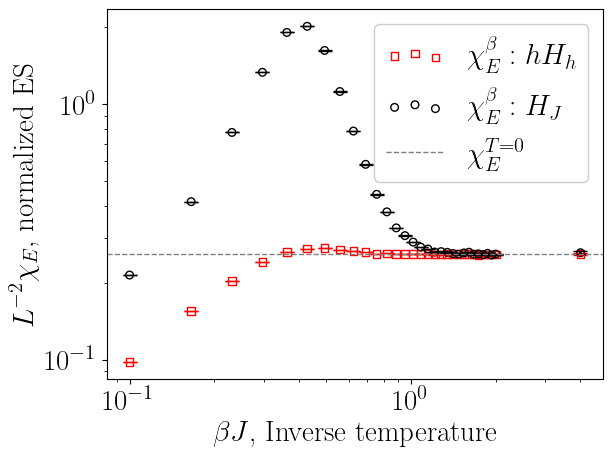

In [4]:
size = 30
plt.scatter(x=df["beta"], y = df["diag_ES_value"], marker='s', s=size, facecolors='none', edgecolors='red', label=r"$\chi_E^{\beta}: hH_h$")
plt.errorbar(x=df["beta"], y = df["diag_ES_value"], yerr=df["diag_FS_std"], fmt='None', color='red', markeredgecolor='blue', capsize=5, capthick=1)
plt.scatter(x=df["beta"], y = df["offdiag_ES_value"], s=size, facecolors='none', edgecolors='black', label=r"$\chi_E^{\beta}: H_J$")
plt.errorbar(x=df["beta"], y = df["offdiag_ES_value"], yerr=df["offdiag_FS_std"], fmt='None', color='black', capsize=5, capthick=1, markeredgecolor='orange')
plt.axhline(y=zero_T_gs_es, color='gray', linestyle='--', linewidth=1, label=r"$\chi_E^{T = 0}$")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#lineplot.set_xlim(0.08, 1.2)
plt.xticks([0.1, 1])
plt.xlabel(r"$\beta J$, Inverse temperature")
plt.ylabel(r"$L^{-2} \chi_E$, normalized ES")
plt.savefig("blackbox_paper_figures/Figure2_to_combine_a.pdf", dpi=800, bbox_inches="tight")

## Fidelity susceptibility plot

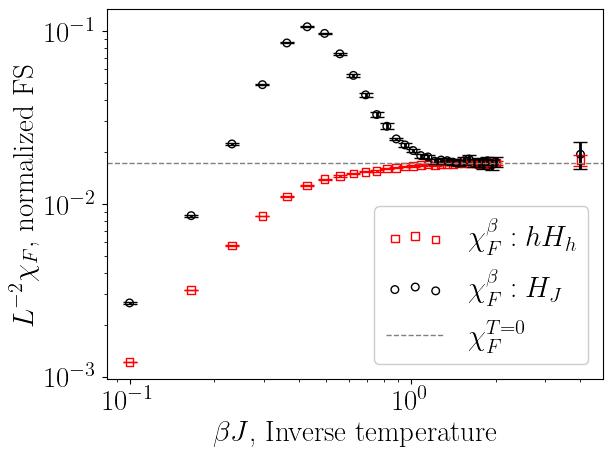

In [3]:
size = 30
plt.scatter(x=df["beta"], y = df["diag_FS_value"], marker='s', s=size, facecolors='none', edgecolors='red', label=r"$\chi_F^{\beta}: hH_h$")
plt.errorbar(x=df["beta"], y = df["diag_FS_value"], yerr=df["diag_FS_std"], fmt='None', color='red', markeredgecolor='red', capsize=5, capthick=1)
plt.scatter(x=df["beta"], y = df["offdiag_FS_value"], s=size, facecolors='none', edgecolors='black', label=r"$\chi_F^{\beta}: H_J$")
plt.errorbar(x=df["beta"], y = df["offdiag_FS_value"], yerr=df["offdiag_FS_std"], fmt='None', color='black', capsize=5, capthick=1, markeredgecolor='black')
#plt.errorbar(x=df["beta"], y = df["offdiag_FS_value"], yerr=df["offdiag_FS_std"], fmt='x', markerfacecolor='none', alpha=0.3, label=r"$H_J$ driver")
plt.axhline(y=zero_T_gs_fs, color='gray', linestyle='--', linewidth=1, label=r"$\chi_F^{T = 0}$")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#lineplot.set_xlim(0.08, 1.2)
plt.xticks([0.1, 1])
plt.xlabel(r"$\beta J$, Inverse temperature")
plt.ylabel(r"$L^{-2} \chi_F$, normalized FS")
plt.savefig("blackbox_paper_figures/Figure2_to_combine_b.pdf", dpi=800, bbox_inches="tight")

# Timing plots/summaries

Text(0, 0.5, 'Time of slowest core (hrs)')

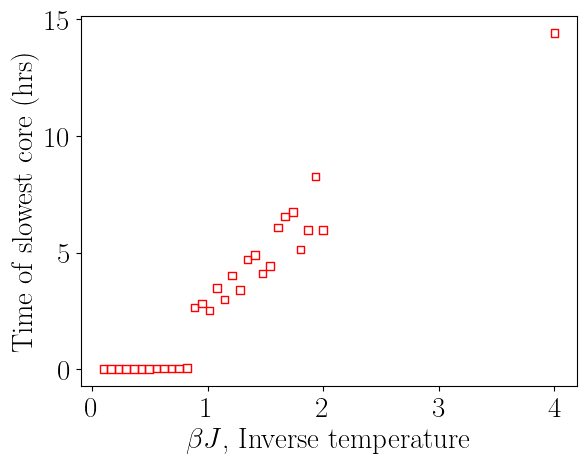

In [13]:
size = 30
plt.scatter(x=df["beta"], y = df["wall_time (s)"] / (60 * 60), marker='s', s=size, facecolors='none', edgecolors='red')
#plt.xscale("log")
plt.xlabel(r"$\beta J$, Inverse temperature")
plt.ylabel(r"Time of slowest core (hrs)")

Text(0, 0.5, '$\\langle q \\rangle$')

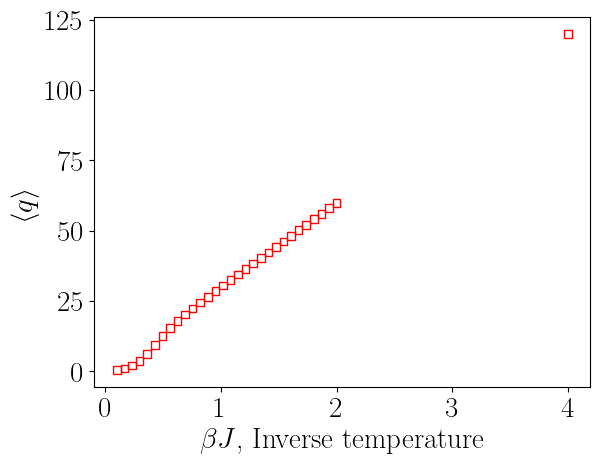

In [47]:
size = 30
plt.scatter(x=df["beta"], y = df["avg_q"], marker='s', s=size, facecolors='none', edgecolors='red')
#plt.xscale("log")
plt.xlabel(r"$\beta J$, Inverse temperature")
plt.ylabel(r"$\langle q \rangle$")

In [15]:
np.sort(df["beta"])

array([0.1       , 0.16551724, 0.23103448, 0.29655172, 0.36206897,
       0.42758621, 0.49310345, 0.55862069, 0.62413793, 0.68965517,
       0.75517241, 0.82068966, 0.8862069 , 0.95172414, 1.01724138,
       1.08275862, 1.14827586, 1.2137931 , 1.27931034, 1.34482759,
       1.41034483, 1.47586207, 1.54137931, 1.60689655, 1.67241379,
       1.73793103, 1.80344828, 1.86896552, 1.93448276, 2.        ,
       4.        ])

In [58]:
print("{:e}".format(min(df["Tsteps"])))
print("{:e}".format(max(df["Tsteps"])))

1.000000e+06
1.000000e+07


In [59]:
print("{:e}".format(min(df["steps"])))
print("{:e}".format(max(df["steps"])))

1.000000e+07
5.000000e+08


In [62]:
print(min(df["wall_time (s)"]))
print(max(df["wall_time (s)"]) / 3600)

15.9421765
14.40596038888889


In [27]:
max(df["steps"])

500000000

In [67]:
min(df["avg_q"]), max(df["avg_q"])

(0.326804, 119.867112)

In [68]:
min(df["avg_sgn"]), max(df["avg_sgn"])

(1, 1)

In [35]:
50000000000 / 500000000

100.0

In [34]:
df["mc_steps"]

0      1000000000
1      1000000000
2      1000000000
3      1000000000
4      1000000000
5      1000000000
6      1000000000
7      1000000000
8      1000000000
9      1000000000
10     1000000000
11     1000000000
12    50000000000
13    50000000000
14    50000000000
15    50000000000
16    50000000000
17    50000000000
18    50000000000
19    50000000000
20    50000000000
21    50000000000
22    50000000000
23    50000000000
24    50000000000
25    50000000000
26    50000000000
27    50000000000
28    50000000000
29    50000000000
30    10000000000
Name: mc_steps, dtype: int64

In [54]:
df.keys()

Index(['beta', 'Hdiag_value', 'Hdiag_std', 'Hoffdiag_value', 'Hoffdiag_std',
       'Hdiag_Eint_value', 'Hdiag_Eint_std', 'Hdiag_Fint_value',
       'Hdiag_Fint_std', 'Hoffdiag_Eint_value', 'Hoffdiag_Eint_std',
       'Hoffdiag_Fint_value', 'Hoffdiag_Fint_std', 'mc_steps', 'avg_q',
       'max_q', 'avg_sgn', 'sgn_std', 'tot_cpu_time (s)', 'wall_time (s)',
       'Tsteps', 'steps', 'Hdiag_test', 'Hoffdiag_test', 'Hdiag_Eint_test',
       'Hdiag_Fint_test', 'Hoffdiag_Eint_test', 'Hoffdiag_Fint_test',
       'diag_ES_value', 'diag_ES_std', 'diag_FS_value', 'diag_FS_std',
       'offdiag_ES_value', 'offdiag_ES_std', 'offdiag_FS_value',
       'offdiag_FS_std'],
      dtype='object')